
# EDA: Helical-Coil R-123 CHF Data — Appendices C/D (`helical_coil_r123_appendixCD.csv`)

Digitized CHF test data for R-123 flow boiling in helical coils, low- and
(where present) higher-pressure appendices. Source document:
`helical_coil_chf_research_data.pdf` (page count checked below for
provenance).

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/helical_coil_r123_appendixCD")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SLUG = "helical_coil_r123_appendixCD"
SLUG_TITLE = "Helical-Coil R-123 CHF (Appendix C/D)"

df = pd.read_csv(DATA_DIR / "helical_coil_r123_appendixCD.csv")

NUMERIC_COLS = ["Lh_mm", "G_kg_m2s", "Psys_bar", "rho_l_over_rho_g", "xe", "Q_watt", "CHF_kW_m2"]
CATEGORICAL_COLS = ["appendix", "Coil_no"]
TARGET_COL = "CHF_kW_m2"

df.head()

,appendix,SN,Coil_no,Lh_mm,G_kg_m2s,Psys_bar,rho_l_over_rho_g,xe,Q_watt,CHF_kW_m2
0,C_low_pressure_R123,1,Coil_1,2146,284,2.11,108.8,1.084,3844,60.0
1,C_low_pressure_R123,2,Coil_1,2146,349,2.36,97.2,1.076,4737,74.0
2,C_low_pressure_R123,3,Coil_1,2146,422,2.58,88.6,1.073,5765,90.0
3,C_low_pressure_R123,4,Coil_1,2146,496,2.82,80.5,1.026,6585,102.8
4,C_low_pressure_R123,5,Coil_1,2146,570,3.07,73.7,1.001,7482,116.8


## 1b. Source Document Provenance

In [2]:
try:
    from pypdf import PdfReader
    reader = PdfReader(DATA_DIR / "helical_coil_chf_research_data.pdf")
    print("Source PDF:", (DATA_DIR / "helical_coil_chf_research_data.pdf").name)
    print("Pages:", len(reader.pages))
except Exception as e:
    print("Could not read source PDF:", e)

Source PDF: helical_coil_chf_research_data.pdf
Pages: 6


## 2. Data Quality

In [3]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing if len(missing) else "None")
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (257, 10)

Dtypes:
appendix             object
SN                    int64
Coil_no              object
Lh_mm                 int64
G_kg_m2s              int64
Psys_bar            float64
rho_l_over_rho_g    float64
xe                  float64
Q_watt                int64
CHF_kW_m2           float64
dtype: object

Missing values per column:
None

Duplicate rows: 0


## 3. Descriptive Statistics

In [4]:
numeric_summary = df[NUMERIC_COLS].describe().T
numeric_summary.to_csv(OUT_DIR / "summary_stats.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Lh_mm,257.0,974.482490,458.107990,467.000,506.00,984.00,1420.000,2146.000
G_kg_m2s,257.0,799.466926,375.072857,145.000,483.00,718.00,1040.000,2062.000
Psys_bar,257.0,3.835681,1.565675,1.740,2.37,3.19,5.380,6.800
rho_l_over_rho_g,257.0,69.978210,30.018860,31.300,40.40,70.70,96.700,131.700
xe,257.0,0.551494,0.328727,-0.056,0.25,0.54,0.856,1.169
Q_watt,257.0,3800.770428,2040.397780,919.000,2287.00,3296.00,4906.000,12186.000
CHF_kW_m2,257.0,180.908560,79.277591,37.700,121.10,165.70,228.800,419.800


## 4. Categorical Value Counts

In [5]:
for col in CATEGORICAL_COLS:
    print(f"--- {col} (n_unique={df[col].nunique(dropna=True)}) ---")
    print(df[col].value_counts(dropna=False).head(15))
    print()

--- appendix (n_unique=2) ---
appendix
C_low_pressure_R123     140
D_high_pressure_R123    117
Name: count, dtype: int64

--- Coil_no (n_unique=6) ---
Coil_no
Coil_1    60
Coil_2    51
Coil_5    47
Coil_6    40
Coil_3    37
Coil_4    22
Name: count, dtype: int64



## 5. Univariate Distributions

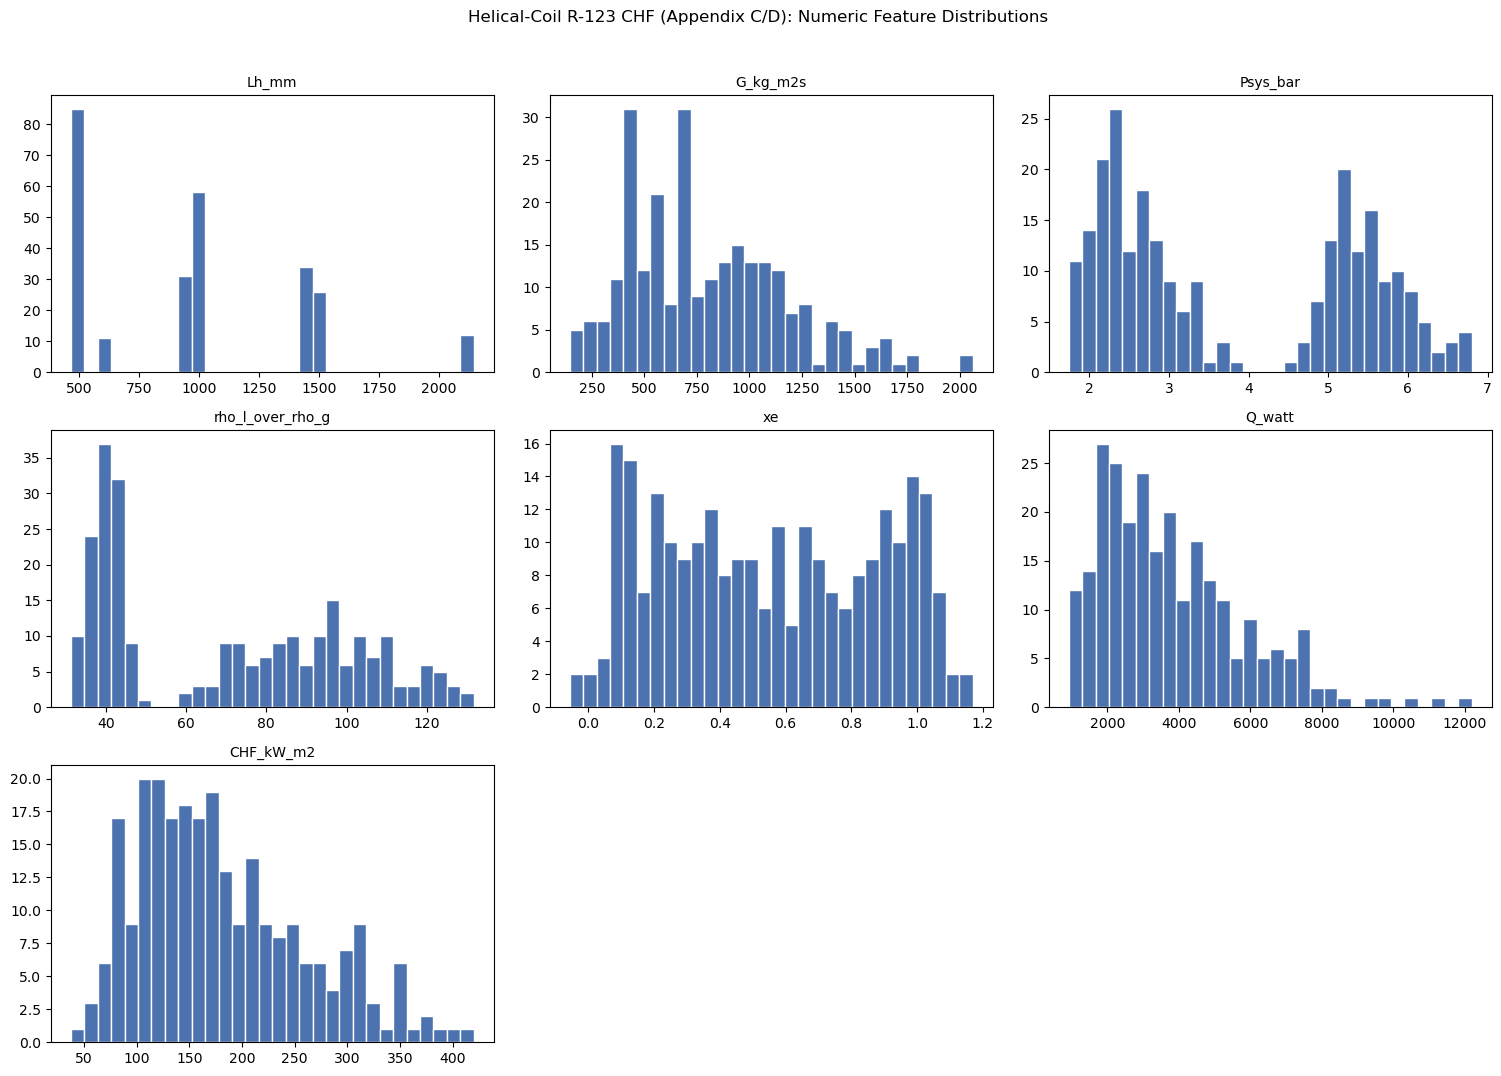

In [6]:
n = len(NUMERIC_COLS)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=10)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: Numeric Feature Distributions", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Outlier Scan (IQR, z-score)

In [7]:
iqr_rows = []
for col in NUMERIC_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    iqr_rows.append({
        "column": col, "q1": q1, "q3": q3, "iqr": iqr,
        "lower_fence": lo, "upper_fence": hi,
        "n_outliers": n_out, "pct_outliers": 100 * n_out / len(s) if len(s) else np.nan,
    })
iqr_table = pd.DataFrame(iqr_rows).set_index("column")
iqr_table.to_csv(OUT_DIR / "iqr_outlier_summary.csv")
iqr_table

,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
column,,,,,,,
Lh_mm,506.00,1420.000,914.000,-865.000,2791.000,0,0.000000
G_kg_m2s,483.00,1040.000,557.000,-352.500,1875.500,2,0.778210
Psys_bar,2.37,5.380,3.010,-2.145,9.895,0,0.000000
rho_l_over_rho_g,40.40,96.700,56.300,-44.050,181.150,0,0.000000
xe,0.25,0.856,0.606,-0.659,1.765,0,0.000000
Q_watt,2287.00,4906.000,2619.000,-1641.500,8834.500,5,1.945525
CHF_kW_m2,121.10,228.800,107.700,-40.450,390.350,2,0.778210


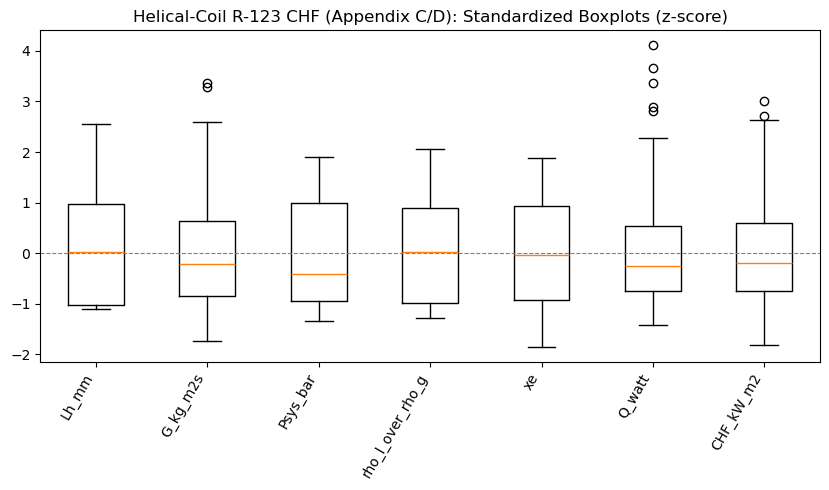

In [8]:
z = df[NUMERIC_COLS].apply(lambda s: (s - s.mean()) / s.std())
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(NUMERIC_COLS)), 5))
ax.boxplot([z[c].dropna() for c in NUMERIC_COLS])
ax.set_xticklabels(NUMERIC_COLS, rotation=60, ha="right")
ax.set_title(f"{SLUG_TITLE}: Standardized Boxplots (z-score)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
fig.tight_layout()
fig.savefig(FIG_DIR / "boxplots_standardized.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlation Structure

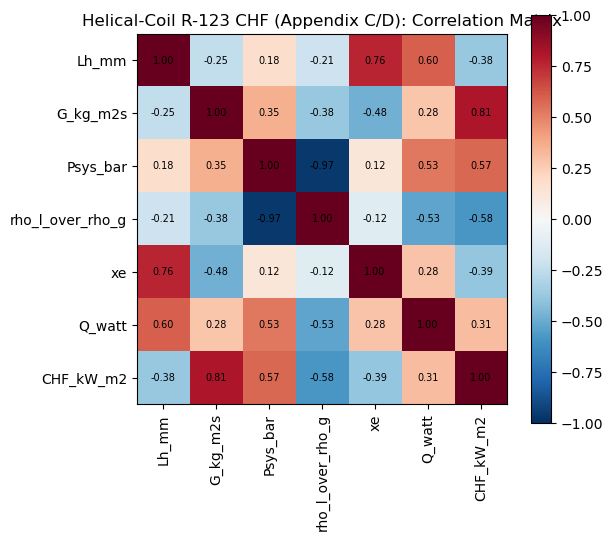

In [9]:
corr = df[NUMERIC_COLS].corr()
corr.to_csv(OUT_DIR / "correlation_matrix.csv")
fig, ax = plt.subplots(figsize=(0.6 * len(NUMERIC_COLS) + 2, 0.6 * len(NUMERIC_COLS) + 2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels(NUMERIC_COLS, rotation=90)
ax.set_yticks(range(len(NUMERIC_COLS)))
ax.set_yticklabels(NUMERIC_COLS)
for i in range(len(NUMERIC_COLS)):
    for j in range(len(NUMERIC_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title(f"{SLUG_TITLE}: Correlation Matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Target vs. Features

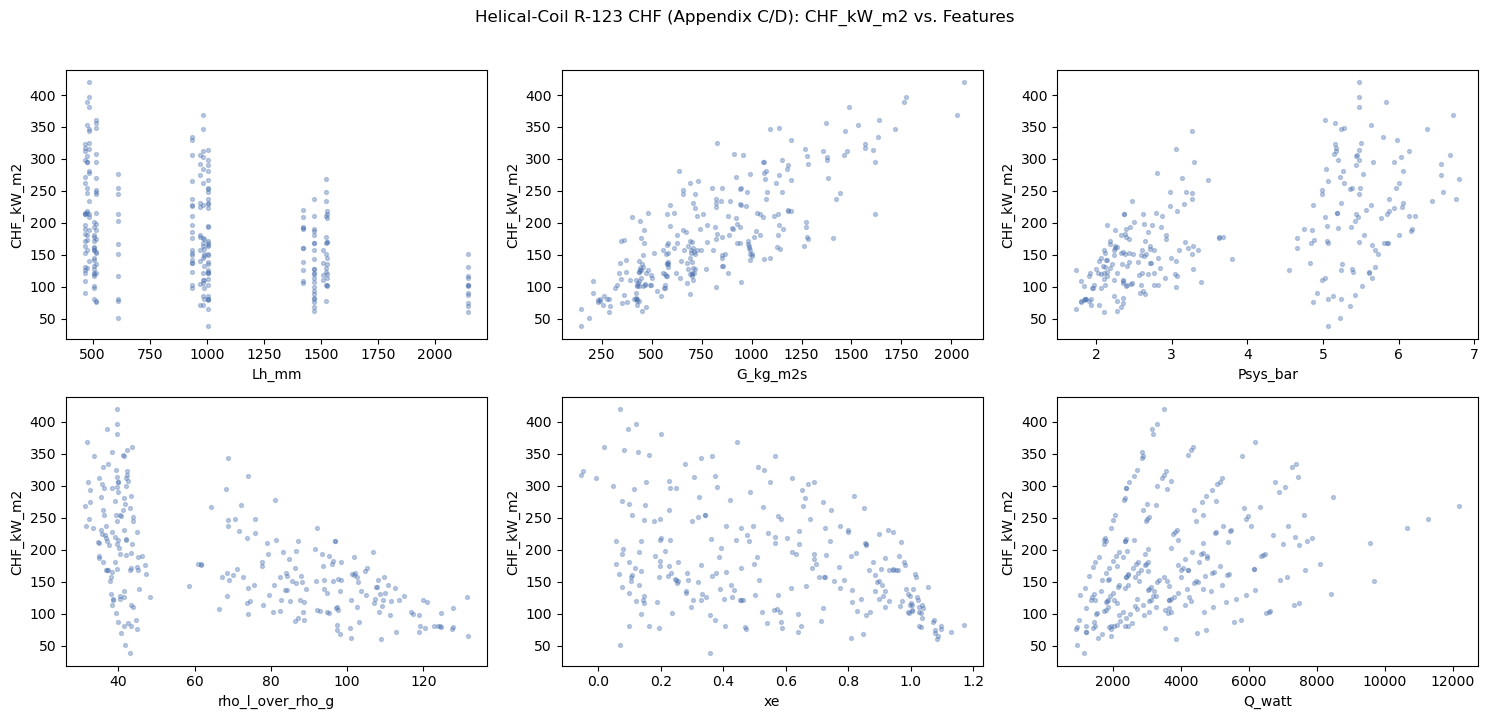

In [10]:
feature_cols = [c for c in NUMERIC_COLS if c != TARGET_COL]
n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df[TARGET_COL], s=8, alpha=0.35, color="#4C72B0")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: {TARGET_COL} vs. Features", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "target_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Target by Category

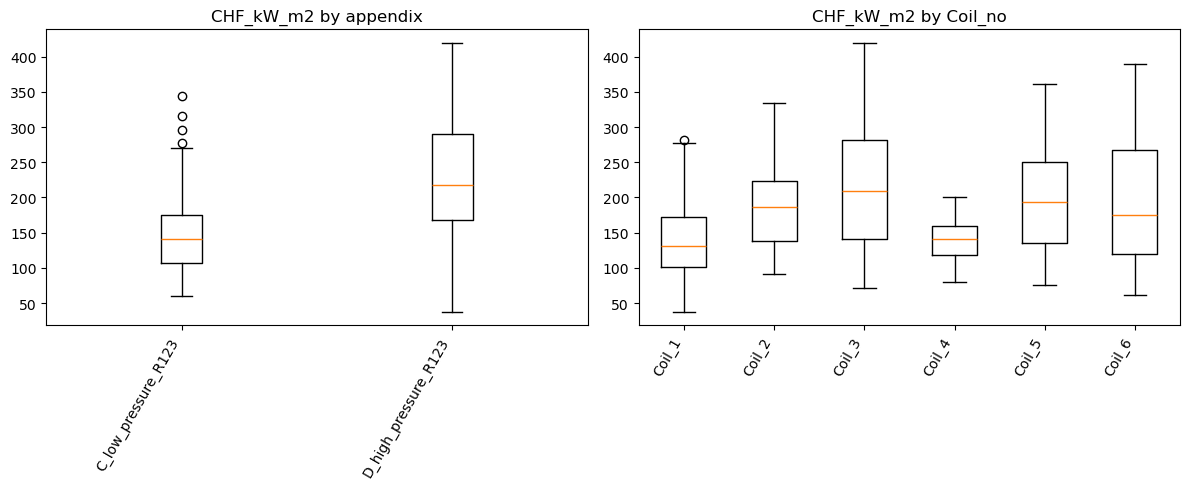

In [11]:
cat_cols_plot = [c for c in CATEGORICAL_COLS
                 if 2 <= df[c].nunique(dropna=True) <= 15]
if cat_cols_plot:
    fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(6 * len(cat_cols_plot), 5), squeeze=False)
    axes = axes[0]
    for ax, col in zip(axes, cat_cols_plot):
        groups = [g[TARGET_COL].dropna().values for _, g in df.groupby(col)]
        labels = [str(k) for k, _ in df.groupby(col)]
        ax.boxplot(groups)
        ax.set_xticklabels(labels, rotation=60, ha="right")
        ax.set_title(f"{TARGET_COL} by {col}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "target_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No low-cardinality categorical columns (2-15 unique values) available for grouped comparison.")


## 10. Takeaways

- `CHF_kW_m2` is the target; `G_kg_m2s` (mass flux), `Psys_bar` (system
  pressure), `xe` (exit quality) and `rho_l_over_rho_g` (density ratio, a
  pressure surrogate) are the physical predictors.
- `appendix` distinguishes the low-pressure vs. other appendix subsets —
  check the target-by-category plot to see whether CHF trends differ by
  appendix before pooling them in a single model.
- `Coil_no` identifies the physical test coil; treat as metadata/grouping
  variable for train/test splitting rather than a physical predictor.
